## SHBT 261 Mini project 1: Image Classification with Caltech-101 Dataset

### Author: Tzu-Hsi (Cece) Jen
### Deadline: March 3rd, 2026 


In [1]:
%pip install --upgrade kagglehub

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import shutil
import random
from pathlib import Path
from tqdm import tqdm
import kagglehub
from sklearn.exceptions import ConvergenceWarning
import warnings

# Data handling
import numpy as np
import pandas as pd
import joblib

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

# Image processing
from PIL import Image
import cv2
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

# Machine learning (HOG + SVM)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

# Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD

/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 0. Function preparation

### 0.1) Function: CNN model building

In [3]:
# Function: CNN model
def cnn_model(
    data_dir="/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data",
    img_size=(64, 64),          
    batch_size=32,
    seed=261,
    use_aug=True,                  
    base_model="ResNet50",        
    dropout=0.3,
    optimizer_name="adam",        
    lr=1e-4,
    momentum=0.9,                 
    epochs=10,
    cache=False,
    ckpt_path="ResNet50_best.keras"
):
    AUTOTUNE = tf.data.AUTOTUNE

    # -----------------------
    # 1) Prepare images
    # -----------------------
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/train",
        image_size=img_size,
        batch_size=batch_size,
        seed=seed,
        label_mode="int",
        shuffle=True
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/val",
        image_size=img_size,
        batch_size=batch_size,
        seed=seed,
        label_mode="int",
        shuffle=False
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/test",
        image_size=img_size,
        batch_size=batch_size,
        seed=seed,
        label_mode="int",
        shuffle=False
    )

    class_names = train_ds.class_names
    num_class = len(class_names)

    def _configure(ds):
        if cache:
            ds = ds.cache()
        return ds.prefetch(AUTOTUNE)

    train_ds = _configure(train_ds)
    val_ds   = _configure(val_ds)
    test_ds  = _configure(test_ds)

    # -----------------------
    # 2) Data augmentation
    # -----------------------
    if use_aug:
        aug_layer = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.10)
        ], name="data_aug")
    else:
        aug_layer = layers.Lambda(lambda x: x, name="no_aug")

    # -----------------------
    # 3) Backbone + preprocess
    # -----------------------
    BaseModel = getattr(tf.keras.applications, base_model)

    base = BaseModel(
        include_top=False,
        weights="imagenet",
        input_shape=img_size + (3,)
    )
    base.trainable = False  # freeze backbone

    # Choose correct preprocess 
    bm = base_model.lower()
    if bm.startswith("resnet"):
        preprocess = tf.keras.applications.resnet.preprocess_input
    elif bm.startswith("efficientnet"):
        preprocess = tf.keras.applications.efficientnet.preprocess_input
    else:
        raise ValueError(f"Unsupported base_model for preprocess: {base_model}")

    # -----------------------
    # 4) Build model
    # -----------------------
    inputs = tf.keras.Input(shape=img_size + (3,))
    x = aug_layer(inputs)
    x = preprocess(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_class, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=f"{base_model}_{img_size[0]}")

    # -----------------------
    # 5) Compile model
    # -----------------------
    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
    else:
        OptimizerClass = getattr(tf.keras.optimizers, optimizer_name)  # fallback
        optimizer = OptimizerClass(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    # -----------------------
    # 6) Callbacks
    # -----------------------
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor="val_loss"),
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, monitor="val_loss"),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.2, monitor="val_loss"),
    ]

    # -----------------------
    # 7) Train
    # -----------------------
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks
    )

    return model, history, (train_ds, val_ds, test_ds), class_names

### 0.2) Function: CNN model evaluation

In [ ]:
# Function: CNN model evaluation
def model_evaluation(
    model=None,
    train=None,
    test=None,
    y_true=None,
    y_pred=None,
    y_pred_probs=None,
    class_names=None,
    cm_k=None,                 
    top_k=None,         
    plot_cm=True,
    model_name=None,
    history=None
    ):
    """
    Parameters
    ----------
    y_true : real labels
    y_pred : predicted labels
    y_pred_probs : predicted probabilities
    class_names : class names in the order of label indices
    cm_k : number of most confused classes to show in the second confusion matrix
    top_k : compute top-k accuracy
    plot_cm : whether to plot confusion matrices for titles
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_classes = len(class_names)

    # ------------------------
    # 1) Overall accuracy
    # ------------------------
    train_loss, train_acc = model.evaluate(train, verbose=0)
    test_loss, test_acc = model.evaluate(test, verbose=0)

    print(f"\nModel: {model_name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Overall (Test) Accuracy: {test_acc:.4f}")

    # ------------------------
    # 2) Top-k accuracy
    # ------------------------
    topk_acc = None
    if top_k is not None:
        if y_pred_probs is None:
            print(f"\nTop-{top_k} accuracy skipped (y_pred_probs not provided)")
        else:
            y_true_onehot = tf.keras.utils.to_categorical(y_true, n_classes)
            metric = tf.keras.metrics.TopKCategoricalAccuracy(k=top_k)
            metric.update_state(y_true_onehot, y_pred_probs)
            topk_acc = float(metric.result())
            print(f"\nTop-{top_k} accuracy: {topk_acc:.4f}")

    # ------------------------
    # 3) Per-class accuracy (for all classes)
    # ------------------------
    cm_norm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes), normalize="true")
    per_class_acc = np.diag(cm_norm)
    
    print("\nPer-class accuracy:")
    per_class_acc_df = pd.DataFrame({
        "class": class_names,
        "accuracy": per_class_acc
    })

    per_class_acc_df = (
    per_class_acc_df
    .assign(accuracy=lambda df: df["accuracy"].round(3))
    .sort_values("accuracy")
    .reset_index(drop=True)
    )

    print(per_class_acc_df)

    # ------------------------
    # 4) Precision / Recall / F1
    # ------------------------
    print("\nPrecision / Recall / F1-score:")
    report_dict = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    # ------------------------
    # 5) Training vs Validation loss
    # ------------------------
    history_dict = history.history

    train_loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]

    epochs = range(1, len(train_loss)+1)

    plt.figure()
    plt.plot(epochs, train_loss, "bo", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title(f"Training and Validation Loss: {model_name}")

    plt.xlabel("Epochs")
    plt.ylabel("Loss (Categorical Crossentropy)")

    plt.legend()
    plt.show()

    # ------------------------
    # 6) Confusion matrix (counts + normalised)
    # ------------------------
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

    # Compute per-class accuracy into per-class error rate (proportion of samples misclassified for each class)
    error_rate = 1 - per_class_acc

    # Exclude classes with zero support in test set (row sum == 0 in raw CM)
    support_per_class = cm.sum(axis=1)
    valid = support_per_class > 0
    valid_idx = np.where(valid)[0]

    # Top-k confused among valid classes
    if cm_k is not None:
        cm_k = min(cm_k, len(valid_idx))

    idx = valid_idx[np.argsort(error_rate[valid_idx])[-cm_k:]] # sort error rates from smallest to largest, choose the last k indices
    idx = idx[np.argsort(error_rate[idx])[::-1]] # reverse -> decending error rates

    # Plot normalised cm
    if plot_cm:
        
        # ------------------------
        # 6.1) Full normalised cm
        # ------------------------
        plt.figure(figsize=(12, 12), dpi=300)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
        disp.plot(xticks_rotation=90, cmap="Blues", colorbar=True, include_values=False)

        disp.ax_.tick_params(axis="x", labelsize=5)
        disp.ax_.tick_params(axis="y", labelsize=5)

        plt.title(f"Confusion Matrix (Normalised): {model_name}")
        plt.tight_layout()
        plt.show()

        # ------------------------
        # 6.2) Top-k normalised cm
        # ------------------------
        cm_top = cm_norm[np.ix_(idx, idx)]
        labels_top = [class_names[i] for i in idx]

        plt.figure(figsize=(12, 12), dpi=300)
        disp_top = ConfusionMatrixDisplay(confusion_matrix=cm_top, display_labels=labels_top)
        disp_top.plot(xticks_rotation=90, cmap="Blues", colorbar=True, values_format=".2f")
    
        disp_top.ax_.tick_params(axis="x", labelsize=5)
        disp_top.ax_.tick_params(axis="y", labelsize=5)

        for text in disp_top.text_.ravel():
            text.set_fontsize(4)
        plt.title(f"Confusion Matrix (Normalised): {model_name}")
        plt.title(f"Top-{cm_k} Most Confused Classes (Normalised): {model_name}")
        plt.tight_layout()
        plt.show()

    print("\nTop confused classes (lowest per-class accuracy):")
    for i in idx:
        print(f"{class_names[i]:<25} acc={per_class_acc[i]:.3f}  err={error_rate[i]:.3f}  support={support_per_class[i]}")

### 0.3) Function: Dataset preparation for HOG+SVM

In [ ]:
def create_dataset(
        data_dir="/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data",
        img_size=(128,128),
        batch_size=32,
        seed=261
):
    AUTOTUNE = tf.data.AUTOTUNE

    train = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/train",
        image_size=img_size,
        batch_size=batch_size,
        seed=seed,
        label_mode="int",
        shuffle=True
    )

    val = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/val",
        image_size=img_size,
        batch_size=batch_size,
        seed=seed,
        label_mode="int",
        shuffle=False
    )

    test = tf.keras.utils.image_dataset_from_directory(
        f"{data_dir}/test",
        image_size=img_size,
        batch_size=batch_size,
        seed=seed,
        label_mode="int",
        shuffle=False
    )

    class_names = train.class_names

    train = train.prefetch(AUTOTUNE)
    val   = val.prefetch(AUTOTUNE)
    test  = test.prefetch(AUTOTUNE)

    return train, val, test, class_names

### 0.4) Function: HOG+SVM model 

In [37]:
#-----------------------------------------
# Function: Convert to numpy
#-----------------------------------------
def ds_to_numpy(ds, verbose=1):
    x_list, y_list = [], []
    iterator = tqdm(ds, desc="Converting dataset to numpy") if verbose else ds

    for x_batch, y_batch in iterator:
        x_list.append(x_batch.numpy())
        y_list.append(y_batch.numpy())

    x = np.concatenate(x_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return x, y


#-----------------------------------
# Function: Extract HOG features
#-----------------------------------
def hog_feature_batch(
    x_rgb,
    out_size=(128, 128),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    verbose=1
):
    features = []
    iterator = tqdm(x_rgb, desc="Extracting HOG features") if verbose else x_rgb

    for img in iterator:
        img = img.astype(np.float32)
        if img.max() > 1.0:
            img = img / 255.0

        g = rgb2gray(img)
        g = resize(g, out_size, anti_aliasing=True)

        f = hog(
            g,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm,
            feature_vector=True
        )
        features.append(f)

    return np.stack(features, axis=0)

#----------------------------
# Function: Train HOG + SVM
#----------------------------
def train_hog_svm_model(
    train=None,
    test=None,
    hog_size=(128, 128),
    C=1.0,
    max_iter=50000, 
    verbose=1
):
    if verbose:
        print("Step 1 — converting datasets")
    x_train_img, y_train = ds_to_numpy(train, verbose)
    x_test_img,  y_test  = ds_to_numpy(test, verbose)

    if verbose:
        print("Step 2 — extracting HOG features (train)")
    x_train = hog_feature_batch(x_train_img, hog_size, verbose=verbose)

    if verbose:
        print("Step 2 — extracting HOG features (test)")
    x_test  = hog_feature_batch(x_test_img, hog_size, verbose=verbose)

    if verbose:
        print("Step 3 — training SVM")

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(C=C, max_iter=max_iter, class_weight="balanced"))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        warnings.simplefilter("ignore", ConvergenceWarning)

        if verbose:
            print("Step 4 — training + predicting")
        clf.fit(x_train, y_train)
        y_pred = clf.predict(x_test)
        scores = clf.decision_function(x_test)

    return clf, x_train, y_train, x_test, y_test, y_pred, scores




### 0.5) Function: HOG+SVM model evaluation

In [38]:
#-----------------------------------
# Function: HOG model top-k accuracy
#-----------------------------------
def hog_top_k_accuracy(y_true, scores, k=5):
    """
    scores: decision scores (n_samples x n_classes)
    """
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    topk = np.argsort(scores, axis=1)[:, -k:]
    hit = np.any(topk == y_true[:, None], axis=1)
    return float(np.mean(hit))


#-----------------------------------
# Function: HOG model evaluation
#-----------------------------------
def hog_evaluate(
    clf,
    x_train, y_train,
    x_test, y_test,
    class_names,
    model_name="HOG + LinearSVC",
    top_k=5,
    cm_k=20,
    plot_cm=True
):
    n_class = len(class_names)

    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        warnings.simplefilter("ignore", ConvergenceWarning)

        # 1) Overall accuracy
        y_train_pred = clf.predict(x_train)
        y_test_pred  = clf.predict(x_test)

        # 2) Top-k accuracy
        test_scores = None
        topk_acc = None
        if top_k is not None:
            test_scores = clf.decision_function(x_test)
            topk_acc = hog_top_k_accuracy(y_test, test_scores, k=top_k)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test, y_test_pred)

    print(f"\nModel: {model_name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    if top_k is not None:
        print(f"Top-{top_k} Accuracy (test): {topk_acc:.4f}")

    # 3) Confusion matrices
    cm_counts = confusion_matrix(y_test, y_test_pred, labels=np.arange(n_class))
    support = cm_counts.sum(axis=1)

    # row-normalisation to avoid divide-by-zero if any class has 0 support
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm_counts / support[:, None]
        cm_norm[~np.isfinite(cm_norm)] = 0.0

    # 4) Per-class accuracy table (diag of row-normalised CM)
    per_class_acc = np.diag(cm_norm)

    per_class_df = (
        pd.DataFrame({
            "class": class_names,
            "accuracy": per_class_acc,
            "support": support
        })
        .assign(accuracy=lambda df: df["accuracy"].round(3))
        .sort_values(["accuracy", "support"], ascending=[True, False])
        .reset_index(drop=True)
    )

    print("\nPer-class accuracy (sorted):")
    print(per_class_df)

    # 5) Precision / Recall / F1 
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_test_pred, average="macro", zero_division=0
    )
    w_p, w_r, w_f1, _ = precision_recall_fscore_support(
        y_test, y_test_pred, average="weighted", zero_division=0
    )

    print("\nClassification report:")
    print(classification_report(
        y_test, y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    # 6) Plot confusion matrices
    if plot_cm:
        plt.figure(figsize=(12, 12), dpi=300)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
        disp.plot(xticks_rotation=90, cmap="Blues", colorbar=True, include_values=False)
        disp.ax_.tick_params(axis="x", labelsize=5)
        disp.ax_.tick_params(axis="y", labelsize=5)
        plt.title(f"Confusion Matrix (Row-normalised): {model_name}")
        plt.tight_layout()
        plt.show()

    # 7) Top confused classes (highest error rate among classes with support>0)
    valid_idx = np.where(support > 0)[0]
    error_rate = 1 - per_class_acc

    if cm_k is None:
        cm_k = len(valid_idx)
    cm_k = min(cm_k, len(valid_idx))

    idx = valid_idx[np.argsort(error_rate[valid_idx])[-cm_k:]]
    idx = idx[np.argsort(error_rate[idx])[::-1]]

    print(f"\nTop {cm_k} confused classes (lowest per-class accuracy):")
    for i in idx:
        print(f"{class_names[i]:<25} acc={per_class_acc[i]:.3f}  err={error_rate[i]:.3f}  support={support[i]}")

    if plot_cm:
        cm_top = cm_norm[np.ix_(idx, idx)]
        labels_top = [class_names[i] for i in idx]

        plt.figure(figsize=(12, 12), dpi=300)
        disp_top = ConfusionMatrixDisplay(confusion_matrix=cm_top, display_labels=labels_top)
        disp_top.plot(xticks_rotation=90, cmap="Blues", colorbar=True, values_format=".2f")
        disp_top.ax_.tick_params(axis="x", labelsize=6)
        disp_top.ax_.tick_params(axis="y", labelsize=6)
        for text in disp_top.text_.ravel():
            text.set_fontsize(5)
        plt.title(f"Top-{cm_k} Most Confused Classes (Row-normalised): {model_name}")
        plt.tight_layout()
        plt.show()

    # 8) Return results
    out = {
        "model_name": model_name,
        "train_acc": float(train_acc),
        "test_acc": float(test_acc),
        "topk_test_acc": float(topk_acc) if topk_acc is not None else None,
        "macro_precision": float(macro_p),
        "weighted_precision": float(w_p),
        "macro_recall": float(macro_r),
        "weighted_recall": float(w_r),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(w_f1),
        "per_class_table": per_class_df,
        "confusion_matrix": cm_counts,
        "confusion_matrix_normalised": cm_norm,
        "top_confused_idx": idx
    }
    return out

## 1) Model 1: ResNet 

### ResNet50: 128x128

Found 6352 files belonging to 102 classes.
Found 1326 files belonging to 102 classes.
Found 1466 files belonging to 102 classes.
Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 58s 273ms/step - accuracy: 0.2916 - loss: 3.8837 - val_accuracy: 0.7768 - val_loss: 0.8858 - learning_rate: 3.0000e-04
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 54s 272ms/step - accuracy: 0.7542 - loss: 0.9450 - val_accuracy: 0.8499 - val_loss: 0.5719 - learning_rate: 3.0000e-04
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 57s 287ms/step - accuracy: 0.8526 - loss: 0.5607 - val_accuracy: 0.8688 - val_loss: 0.4859 - learning_rate: 3.0000e-04
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 61s 309ms/step - accuracy: 0.8834 - loss: 0.4192 - val_accuracy: 0.8891 - val_loss: 0.4426 - learning_rate: 3.0000e-04
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 63s 318ms/step - accuracy: 0.9127 - loss: 0.3266 - val_accuracy: 0.8808 - val_loss: 0.4297 - learning_rate: 3.0000e-04
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 59s 295ms/step - accuracy: 0.9257 - 

2026-03-01 09:42:50.295308: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 269ms/step

Model: ResNet50 (128x128), Adam optimiser
Train Accuracy: 0.9912
Overall (Test) Accuracy: 0.8909

Top-5 accuracy: 0.9775

Per-class accuracy:
         class  accuracy
0      octopus     0.167
1      lobster     0.286
2     schooner     0.500
3        chair     0.500
4    crocodile     0.500
..         ...       ...
97   saxophone     1.000
98      laptop     1.000
99     gerenuk     1.000
100  cellphone     1.000
101     camera     1.000

[102 rows x 2 columns]

Precision / Recall / F1-score:
                   precision    recall  f1-score   support

BACKGROUND_Google     0.6067    0.7606    0.6750        71
            Faces     0.9851    1.0000    0.9925        66
       Faces_easy     0.9848    0.9848    0.9848        66
         Leopards     1.0000    0.9667    0.9831        30
       Motorbikes     0.9917    0.9917    0.9917       121
        accordion     0.9000    1.0000    0.9474         9
        airplanes     0.9836    1.0000    0.9

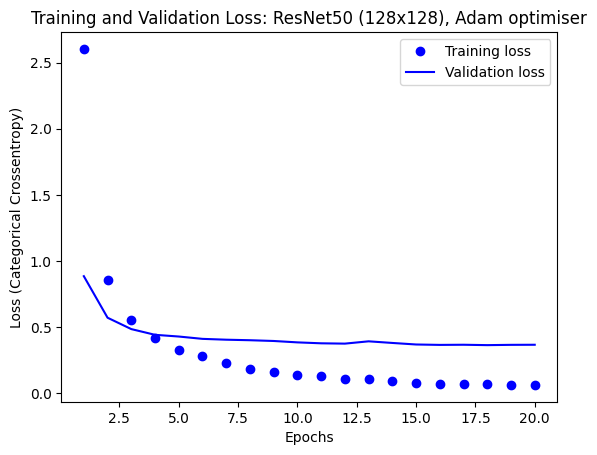

<Figure size 3600x3600 with 0 Axes>

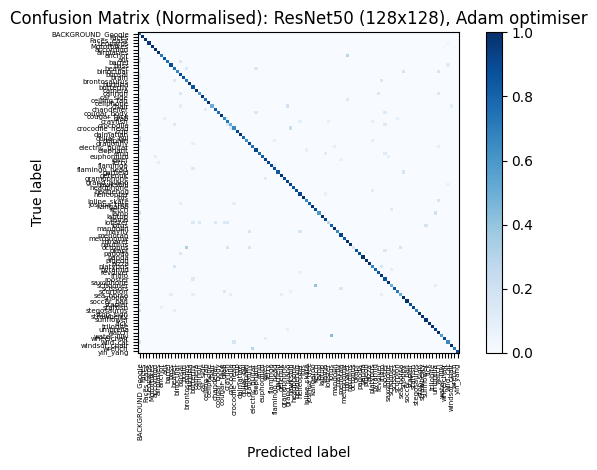

<Figure size 3600x3600 with 0 Axes>

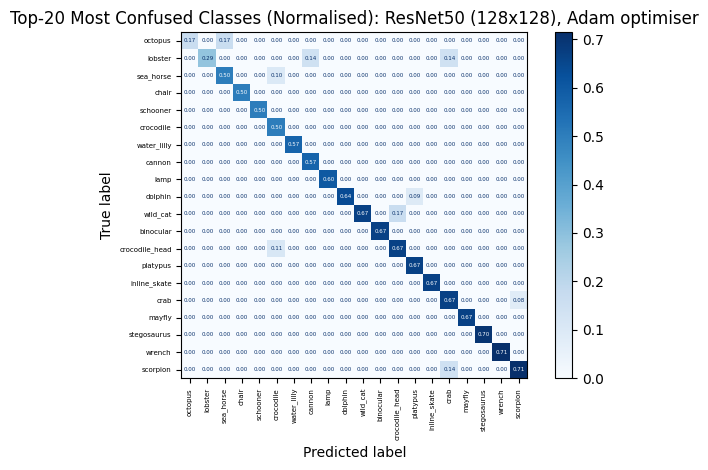


Top confused classes (lowest per-class accuracy):
octopus                   acc=0.167  err=0.833  support=6
lobster                   acc=0.286  err=0.714  support=7
sea_horse                 acc=0.500  err=0.500  support=10
chair                     acc=0.500  err=0.500  support=10
schooner                  acc=0.500  err=0.500  support=10
crocodile                 acc=0.500  err=0.500  support=8
water_lilly               acc=0.571  err=0.429  support=7
cannon                    acc=0.571  err=0.429  support=7
lamp                      acc=0.600  err=0.400  support=10
dolphin                   acc=0.636  err=0.364  support=11
wild_cat                  acc=0.667  err=0.333  support=6
binocular                 acc=0.667  err=0.333  support=6
crocodile_head            acc=0.667  err=0.333  support=9
platypus                  acc=0.667  err=0.333  support=6
inline_skate              acc=0.667  err=0.333  support=6
crab                      acc=0.667  err=0.333  support=12
mayfly         

In [6]:
# Model: 128x128, Adam optimiser
model_resnet128, history_resnet128, (train_resnet128, val_resnet128, test_resnet128), classNames_resnet128 = cnn_model(
    data_dir="/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data",
    img_size=(128, 128),          
    batch_size=32,
    seed=261,
    use_aug=True,                  
    base_model="ResNet50",        
    dropout=0.2,
    optimizer_name="adam",        
    lr=3e-4,
    momentum=0.9,                 
    epochs=20,
    cache=False,
    ckpt_path="ResNet50_128_best.keras"
)

# Model evaluation: 128x128, Adam optimiser
# parameters: model_resnet128, history_resnet128, (train_resnet128, val_resnet128, test_resnet128), classNames_resnet128

y_true = np.concatenate([y for x,y in test_resnet128])
y_pred_probs = model_resnet128.predict(test_resnet128)
y_pred = y_pred_probs.argmax(axis=1)

model_evaluation(
    model_resnet128,
    train_resnet128,
    test_resnet128,
    y_true,
    y_pred,
    y_pred_probs=y_pred_probs,
    class_names=classNames_resnet128,
    cm_k=20,                 
    top_k=5,         
    plot_cm=True,
    model_name="ResNet50 (128x128), Adam optimiser",
    history=history_resnet128
    )

## 2) Model 2: EfficientNet


## 2.1) Image size comparison
64x64, 128x128

### Image size: 64x64

Found 6352 files belonging to 102 classes.
Found 1326 files belonging to 102 classes.
Found 1466 files belonging to 102 classes.
Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.1598 - loss: 4.0953 - val_accuracy: 0.3959 - val_loss: 2.8480 - learning_rate: 3.0000e-04
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.3956 - loss: 2.7692 - val_accuracy: 0.5709 - val_loss: 2.1919 - learning_rate: 3.0000e-04
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.5363 - loss: 2.1531 - val_accuracy: 0.6516 - val_loss: 1.8001 - learning_rate: 3.0000e-04
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.6111 - loss: 1.8144 - val_accuracy: 0.6938 - val_loss: 1.5547 - learning_rate: 3.0000e-04
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6520 - loss: 1.5789 - val_accuracy: 0.7127 - val_loss: 1.3930 - learning_rate: 3.0000e-04
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6846 - loss: 1.420

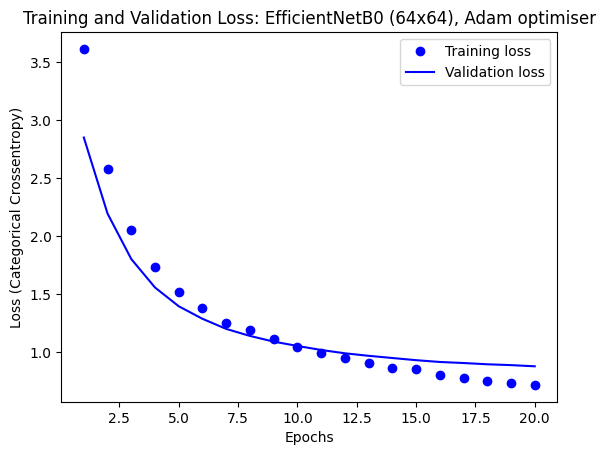

<Figure size 3600x3600 with 0 Axes>

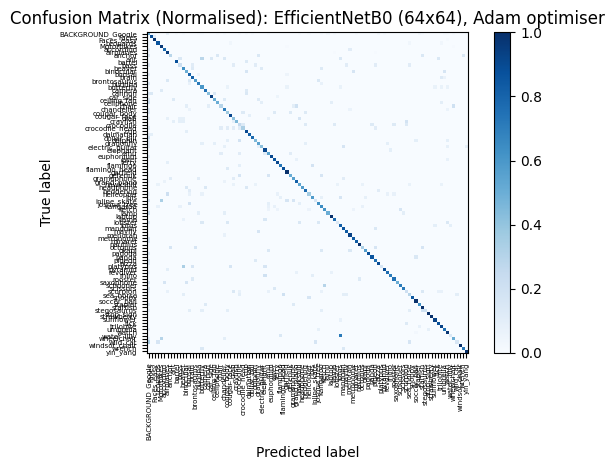

<Figure size 3600x3600 with 0 Axes>

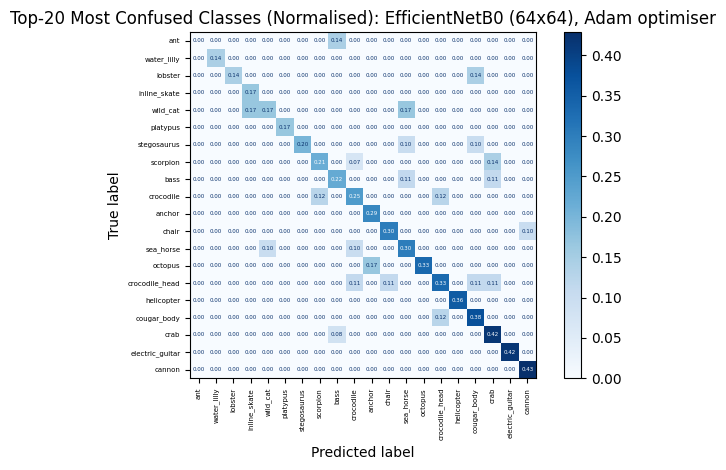


Top confused classes (lowest per-class accuracy):
ant                       acc=0.000  err=1.000  support=7
water_lilly               acc=0.143  err=0.857  support=7
lobster                   acc=0.143  err=0.857  support=7
inline_skate              acc=0.167  err=0.833  support=6
wild_cat                  acc=0.167  err=0.833  support=6
platypus                  acc=0.167  err=0.833  support=6
stegosaurus               acc=0.200  err=0.800  support=10
scorpion                  acc=0.214  err=0.786  support=14
bass                      acc=0.222  err=0.778  support=9
crocodile                 acc=0.250  err=0.750  support=8
anchor                    acc=0.286  err=0.714  support=7
chair                     acc=0.300  err=0.700  support=10
sea_horse                 acc=0.300  err=0.700  support=10
octopus                   acc=0.333  err=0.667  support=6
crocodile_head            acc=0.333  err=0.667  support=9
helicopter                acc=0.357  err=0.643  support=14
cougar_body     

In [9]:
# Model: 64x64, Adam optimiser
model_eff64, history_eff64, (train_eff64, val_eff64, test_eff64), classNames_eff64 = cnn_model(
    data_dir="/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data",
    img_size=(64, 64),          
    batch_size=32,
    seed=261,
    use_aug=True,                  
    base_model="EfficientNetB0",        
    dropout=0.2,
    optimizer_name="adam",        
    lr=3e-4,
    momentum=0.9,                 
    epochs=20,
    cache=False,
    ckpt_path="EfficientNetB0_64_best.keras"
)

# Model evaluation: 64x64, Adam optimiser
# parameters: model_eff64, history_eff64, (train_eff64, val_eff64, test_eff64), classNames_eff64

y_true = np.concatenate([y for x,y in test_eff64])
y_pred_probs = model_eff64.predict(test_eff64)
y_pred = y_pred_probs.argmax(axis=1)

model_evaluation(
    model_eff64,
    train_eff64,
    test_eff64,
    y_true,
    y_pred,
    y_pred_probs=y_pred_probs,
    class_names=classNames_eff64,
    cm_k=20,                 
    top_k=5,         
    plot_cm=True,
    model_name="EfficientNetB0 (64x64), Adam optimiser",
    history=history_eff64
    )

### Image size: 128x128

Found 6352 files belonging to 102 classes.
Found 1326 files belonging to 102 classes.
Found 1466 files belonging to 102 classes.
Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.2085 - loss: 3.9431 - val_accuracy: 0.7270 - val_loss: 2.1174 - learning_rate: 3.0000e-04
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.7048 - loss: 1.8778 - val_accuracy: 0.8333 - val_loss: 1.2195 - learning_rate: 3.0000e-04
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - accuracy: 0.8180 - loss: 1.1393 - val_accuracy: 0.8733 - val_loss: 0.8413 - learning_rate: 3.0000e-04
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.8690 - loss: 0.8021 - val_accuracy: 0.8876 - val_loss: 0.6581 - learning_rate: 3.0000e-04
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.8961 - loss: 0.6250 - val_accuracy: 0.9012 - val_loss: 0.5582 - learning_rate: 3.0000e-04
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - accuracy: 0.9084 - lo

2026-03-01 10:38:04.178759: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step

Model: EfficientNetB0 (128x128), Adam optimiser
Train Accuracy: 0.9817
Overall (Test) Accuracy: 0.9120

Top-5 accuracy: 0.9843

Per-class accuracy:
                 class  accuracy
0          water_lilly     0.143
1              lobster     0.286
2    BACKGROUND_Google     0.563
3               cannon     0.571
4            crocodile     0.625
..                 ...       ...
97           metronome     1.000
98             minaret     1.000
99            nautilus     1.000
100           flamingo     1.000
101           yin_yang     1.000

[102 rows x 2 columns]

Precision / Recall / F1-score:
                   precision    recall  f1-score   support

BACKGROUND_Google     0.8000    0.5634    0.6612        71
            Faces     0.9552    0.9697    0.9624        66
       Faces_easy     0.9552    0.9697    0.9624        66
         Leopards     0.9667    0.9667    0.9667        30
       Motorbikes     1.0000    1.0000    1.0000       121
   

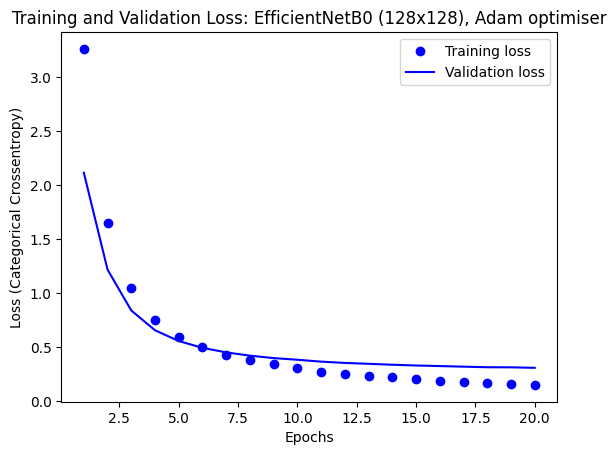

<Figure size 3600x3600 with 0 Axes>

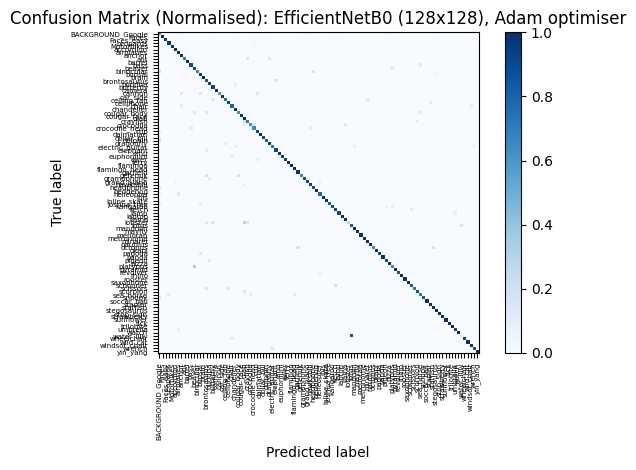

<Figure size 3600x3600 with 0 Axes>

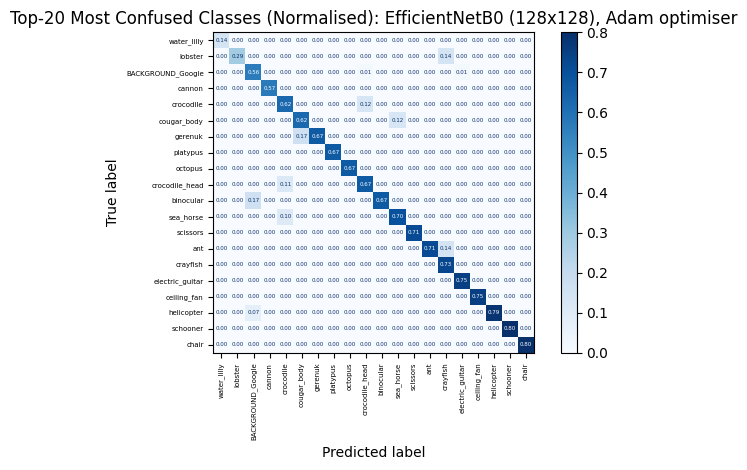


Top confused classes (lowest per-class accuracy):
water_lilly               acc=0.143  err=0.857  support=7
lobster                   acc=0.286  err=0.714  support=7
BACKGROUND_Google         acc=0.563  err=0.437  support=71
cannon                    acc=0.571  err=0.429  support=7
crocodile                 acc=0.625  err=0.375  support=8
cougar_body               acc=0.625  err=0.375  support=8
gerenuk                   acc=0.667  err=0.333  support=6
platypus                  acc=0.667  err=0.333  support=6
octopus                   acc=0.667  err=0.333  support=6
crocodile_head            acc=0.667  err=0.333  support=9
binocular                 acc=0.667  err=0.333  support=6
sea_horse                 acc=0.700  err=0.300  support=10
scissors                  acc=0.714  err=0.286  support=7
ant                       acc=0.714  err=0.286  support=7
crayfish                  acc=0.727  err=0.273  support=11
electric_guitar           acc=0.750  err=0.250  support=12
ceiling_fan      

In [10]:
# Model: 128x128, Adam optimiser
model_eff128, history_eff128, (train_eff128, val_eff128, test_eff128), classNames_eff128 = cnn_model(
    data_dir="/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data",
    img_size=(128, 128),          
    batch_size=32,
    seed=261,
    use_aug=True,                  
    base_model="EfficientNetB0",        
    dropout=0.2,
    optimizer_name="adam",        
    lr=3e-4,
    momentum=0.9,                 
    epochs=20,
    cache=False,
    ckpt_path="EfficientNetB0_128_best.keras"
)

# Model evaluation: 128x128, Adam optimiser
# parameters: model_eff128, history_eff128, (train_eff128, val_eff128, test_eff128), classNames_eff128 

y_true = np.concatenate([y for x,y in test_eff128])
y_pred_probs = model_eff128.predict(test_eff128)
y_pred = y_pred_probs.argmax(axis=1)

model_evaluation(
    model_eff128,
    train_eff128,
    test_eff128,
    y_true,
    y_pred,
    y_pred_probs=y_pred_probs,
    class_names=classNames_eff128,
    cm_k=20,                 
    top_k=5,         
    plot_cm=True,
    model_name="EfficientNetB0 (128x128), Adam optimiser",
    history=history_eff128
    )

## 2.2) Optimiser comparison
Adam vs SGD

### Optimiser: SGD

Found 6352 files belonging to 102 classes.
Found 1326 files belonging to 102 classes.
Found 1466 files belonging to 102 classes.
Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.0545 - loss: 4.5912 - val_accuracy: 0.2308 - val_loss: 4.0631 - learning_rate: 3.0000e-04
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - accuracy: 0.2262 - loss: 3.9549 - val_accuracy: 0.3333 - val_loss: 3.5804 - learning_rate: 3.0000e-04
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.3000 - loss: 3.5202 - val_accuracy: 0.3906 - val_loss: 3.2519 - learning_rate: 3.0000e-04
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - accuracy: 0.3477 - loss: 3.2608 - val_accuracy: 0.4480 - val_loss: 3.0187 - learning_rate: 3.0000e-04
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.3867 - loss: 3.0499 - val_accuracy: 0.5023 - val_loss: 2.8342 - learning_rate: 3.0000e-04
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.4353 - los

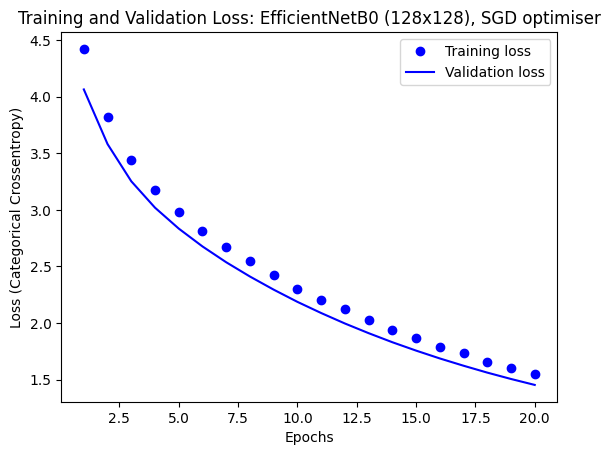

<Figure size 3600x3600 with 0 Axes>

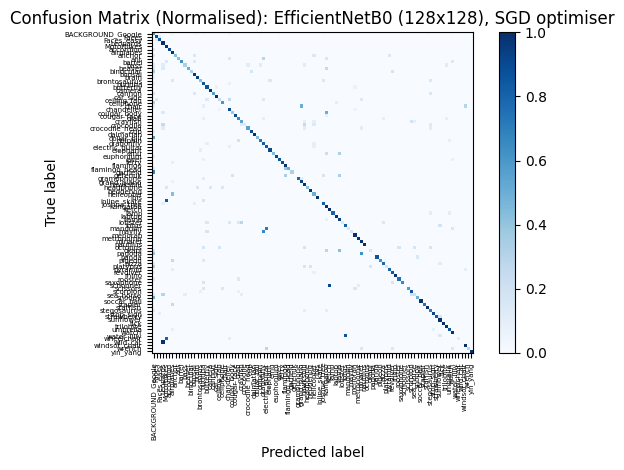

<Figure size 3600x3600 with 0 Axes>

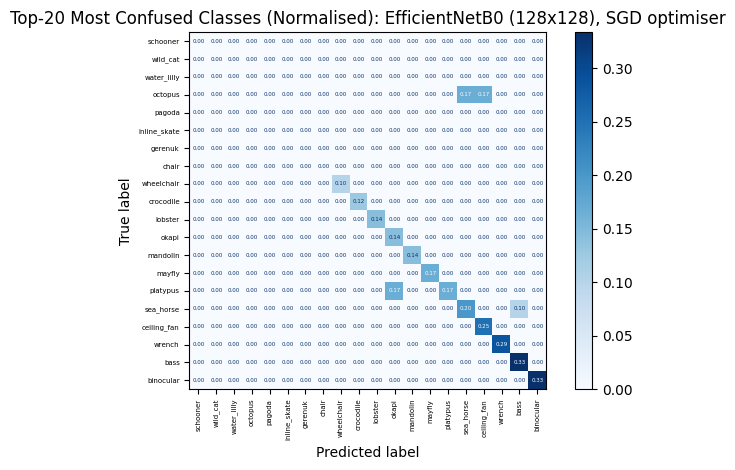


Top confused classes (lowest per-class accuracy):
schooner                  acc=0.000  err=1.000  support=10
wild_cat                  acc=0.000  err=1.000  support=6
water_lilly               acc=0.000  err=1.000  support=7
octopus                   acc=0.000  err=1.000  support=6
pagoda                    acc=0.000  err=1.000  support=8
inline_skate              acc=0.000  err=1.000  support=6
gerenuk                   acc=0.000  err=1.000  support=6
chair                     acc=0.000  err=1.000  support=10
wheelchair                acc=0.100  err=0.900  support=10
crocodile                 acc=0.125  err=0.875  support=8
lobster                   acc=0.143  err=0.857  support=7
okapi                     acc=0.143  err=0.857  support=7
mandolin                  acc=0.143  err=0.857  support=7
mayfly                    acc=0.167  err=0.833  support=6
platypus                  acc=0.167  err=0.833  support=6
sea_horse                 acc=0.200  err=0.800  support=10
ceiling_fan      

In [11]:
# Model: 128x128, SGD optimiser
model_eff128_sgd, history_eff128_sgd, (train_eff128_sgd, val_eff128_sgd, test_eff128_sgd), classNames_eff128_sgd = cnn_model(
    data_dir="/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data",
    img_size=(128, 128),          
    batch_size=32,
    seed=261,
    use_aug=True,                  
    base_model="EfficientNetB0",        
    dropout=0.2,
    optimizer_name="sgd",        
    lr=3e-4,
    momentum=0.9,                 
    epochs=20,
    cache=False,
    ckpt_path="EfficientNetB0_128_sgd_best.keras"
)

# Model evaluation: 128x128, SGD optimiser
# parameters: model_eff128_sgd, history_eff128_sgd, (train_eff128_sgd, val_eff128_sgd, test_eff128_sgd), classNames_eff128_sgd

y_true = np.concatenate([y for x,y in test_eff128_sgd], axis=0)
y_pred_probs = model_eff128_sgd.predict(test_eff128_sgd)
y_pred = y_pred_probs.argmax(axis=1)

model_evaluation(
    model_eff128_sgd,
    train_eff128_sgd,
    test_eff128_sgd,
    y_true,
    y_pred,
    y_pred_probs=y_pred_probs,
    class_names=classNames_eff128_sgd,
    cm_k=20,                 
    top_k=5,         
    plot_cm=True,
    model_name="EfficientNetB0 (128x128), SGD optimiser",
    history=history_eff128_sgd
    )

## 3) Model 3: HOG + SVM 

### Image size: 128x128

In [39]:

train_hog128, val_hog128, test_hog128, class_names_hog128 = create_dataset(
        data_dir="/Users/cece711/Desktop/Harvard/Year2/SHBT261/SHBT261_MiniProject1_CeceJen/data",
        img_size=(128,128),
        batch_size=32,
        seed=261
)

Found 6352 files belonging to 102 classes.
Found 1326 files belonging to 102 classes.
Found 1466 files belonging to 102 classes.


In [40]:
hog_model, x_train_hog, y_train_hog, x_test_hog, y_test_hog, y_pred_hog, y_pred_scores_hog = train_hog_svm_model(
    train=train_hog128,
    test=test_hog128,
    hog_size=(128, 128),
    C=1,
    max_iter=50000, 
    verbose=1
)


import joblib
joblib.dump(hog_model, "hog_svm_model.joblib")

np.save("x_train_hog.npy", x_train_hog)
np.save("x_test_hog.npy", x_test_hog)

np.save("y_train_hog.npy", y_train_hog)
np.save("y_test_hog.npy", y_test_hog)

np.save("y_pred_hog.npy", y_pred_hog)
np.save("y_pred_scores_hog.npy", y_pred_scores_hog)

Step 1 — converting datasets


Converting dataset to numpy:   0%|          | 0/199 [00:00<?, ?it/s]

Converting dataset to numpy:   0%|          | 0/46 [00:00<?, ?it/s]

Step 2 — extracting HOG features (train)


Extracting HOG features:   0%|          | 0/6352 [00:00<?, ?it/s]

Step 2 — extracting HOG features (test)


Extracting HOG features:   0%|          | 0/1466 [00:00<?, ?it/s]

Step 3 — training SVM
Step 4 — training + predicting


In [ ]:
# hog_model = joblib.load("hog_svm_model.joblib")

# x_train_hog = np.load("x_train_hog.npy")
# x_test_hog = np.load("x_test_hog.npy")
# y_train_hog = np.load("y_train_hog.npy")
# y_test_hog = np.load("y_test_hog.npy")
# y_pred_hog = np.load("y_pred_hog.npy")
# y_pred_scores_hog = np.load("y_pred_scores_hog.npy")


Model: HOG + SVM
Train Accuracy: 1.0000
Test Accuracy:  0.4386
Top-5 Accuracy (test): 0.5887

Per-class accuracy (sorted):
           class  accuracy  support
0           crab     0.000       12
1      dalmatian     0.000       11
2       flamingo     0.000       11
3    joshua_tree     0.000       11
4            cup     0.000       10
..           ...       ...      ...
97       minaret     0.917       12
98     trilobite     0.929       14
99     airplanes     0.950      120
100   Faces_easy     0.970       66
101   Motorbikes     0.992      121

[102 rows x 3 columns]

Classification report:
                   precision    recall  f1-score   support

BACKGROUND_Google     0.1641    0.2958    0.2111        71
            Faces     0.4754    0.8788    0.6170        66
       Faces_easy     0.5664    0.9697    0.7151        66
         Leopards     0.3846    0.8333    0.5263        30
       Motorbikes     0.7792    0.9917    0.8727       121
        accordion     0.8571    0.6667   

<Figure size 3600x3600 with 0 Axes>

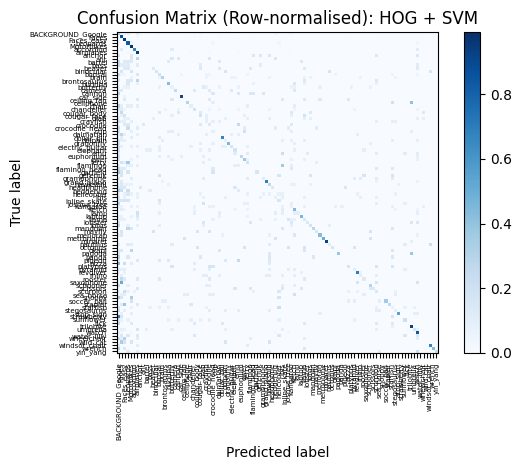


Top 20 confused classes (lowest per-class accuracy):
hedgehog                  acc=0.000  err=1.000  support=9
saxophone                 acc=0.000  err=1.000  support=6
emu                       acc=0.000  err=1.000  support=9
cup                       acc=0.000  err=1.000  support=10
crocodile_head            acc=0.000  err=1.000  support=9
flamingo                  acc=0.000  err=1.000  support=11
flamingo_head             acc=0.000  err=1.000  support=8
gerenuk                   acc=0.000  err=1.000  support=6
crab                      acc=0.000  err=1.000  support=12
inline_skate              acc=0.000  err=1.000  support=6
joshua_tree               acc=0.000  err=1.000  support=11
cougar_body               acc=0.000  err=1.000  support=8
ceiling_fan               acc=0.000  err=1.000  support=8
cannon                    acc=0.000  err=1.000  support=7
okapi                     acc=0.000  err=1.000  support=7
panda                     acc=0.000  err=1.000  support=7
pigeon        

<Figure size 3600x3600 with 0 Axes>

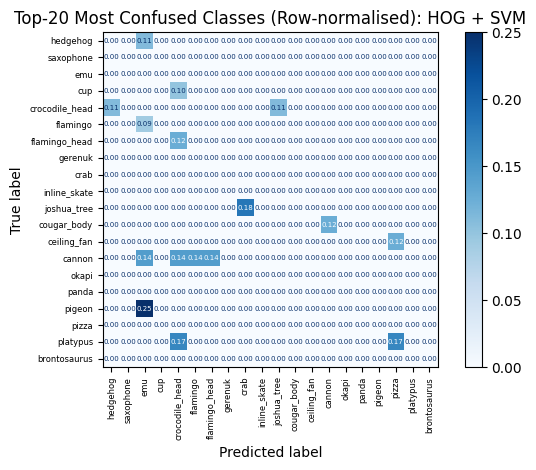

{'model_name': 'HOG + SVM',
 'train_acc': 1.0,
 'test_acc': 0.43860845839017737,
 'topk_test_acc': 0.5886766712141883,
 'macro_precision': 0.3584958621309154,
 'weighted_precision': 0.42940429174231015,
 'macro_recall': 0.23344005458417563,
 'weighted_recall': 0.43860845839017737,
 'macro_f1': 0.2517081314343484,
 'weighted_f1': 0.39894358553058473,
 'per_class_table':            class  accuracy  support
 0           crab     0.000       12
 1      dalmatian     0.000       11
 2       flamingo     0.000       11
 3    joshua_tree     0.000       11
 4            cup     0.000       10
 ..           ...       ...      ...
 97       minaret     0.917       12
 98     trilobite     0.929       14
 99     airplanes     0.950      120
 100   Faces_easy     0.970       66
 101   Motorbikes     0.992      121
 
 [102 rows x 3 columns],
 'confusion_matrix': array([[21,  4,  4, ...,  0,  0,  0],
        [ 1, 58,  2, ...,  0,  0,  0],
        [ 0,  1, 64, ...,  0,  0,  0],
        ...,
        

In [41]:
# parameters: hog_model, x_train_hog, y_train_hog, x_test_hog, y_test_hog, y_pred_hog, y_pred_scores_hog
hog_evaluate(
        hog_model,
        x_train_hog, y_train_hog,
        x_test_hog, y_test_hog,
        class_names_hog128,
        model_name="HOG + SVM",
        top_k=5,
        cm_k=20,
        plot_cm=True
        )